In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
dataset = pd.read_csv('Wine.csv')
X = dataset.iloc[:, :-1].values
y = dataset.iloc[:, -1].values

In [3]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=0
)

# Standardize
sc = StandardScaler()
X_train_scaled = sc.fit_transform(X_train)
X_test_scaled = sc.transform(X_test)

In [4]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix

# Baseline: original standardized features
baseline_clf = LogisticRegression(random_state=0, max_iter=1000)
baseline_clf.fit(X_train_scaled, y_train)

y_pred_base = baseline_clf.predict(X_test_scaled)

print("Baseline (original features) confusion matrix:")
print(confusion_matrix(y_test, y_pred_base))
print("Baseline accuracy:", accuracy_score(y_test, y_pred_base))

Baseline (original features) confusion matrix:
[[14  0  0]
 [ 0 16  0]
 [ 0  0  6]]
Baseline accuracy: 1.0


In [5]:
from sklearn.decomposition import PCA

pca = PCA(n_components=2)
X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Total variance retained:", pca.explained_variance_ratio_.sum())

Explained variance ratio: [0.36884109 0.19318394]
Total variance retained: 0.5620250359227309


In [6]:
pca_clf = LogisticRegression(random_state=0, max_iter=1000)
pca_clf.fit(X_train_pca, y_train)

y_pred_pca = pca_clf.predict(X_test_pca)

print("\nPCA (2 components) confusion matrix:")
print(confusion_matrix(y_test, y_pred_pca))
print("PCA accuracy:", accuracy_score(y_test, y_pred_pca))


PCA (2 components) confusion matrix:
[[14  0  0]
 [ 1 15  0]
 [ 0  0  6]]
PCA accuracy: 0.9722222222222222


In [7]:
print("\n--- Comparison ---")
print("Original feature dimension:", X_train_scaled.shape[1])
print("PCA feature dimension:", X_train_pca.shape[1])
print("Baseline accuracy:", accuracy_score(y_test, y_pred_base))
print("PCA accuracy:", accuracy_score(y_test, y_pred_pca))
print("Variance retained by 2 PCs:", pca.explained_variance_ratio_.sum())


--- Comparison ---
Original feature dimension: 13
PCA feature dimension: 2
Baseline accuracy: 1.0
PCA accuracy: 0.9722222222222222
Variance retained by 2 PCs: 0.5620250359227309


In [8]:
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

results = []

for k in range(1, X_train_scaled.shape[1] + 1):
    pca_k = PCA(n_components=k)
    X_train_k = pca_k.fit_transform(X_train_scaled)
    X_test_k = pca_k.transform(X_test_scaled)

    clf_k = LogisticRegression(random_state=0, max_iter=1000)
    clf_k.fit(X_train_k, y_train)
    y_pred_k = clf_k.predict(X_test_k)

    results.append([
        k,
        pca_k.explained_variance_ratio_.sum(),
        accuracy_score(y_test, y_pred_k)
    ])

for row in results:
    print(f"k={row[0]:2d}, variance retained={row[1]:.4f}, accuracy={row[2]:.4f}")

k= 1, variance retained=0.3688, accuracy=0.8056
k= 2, variance retained=0.5620, accuracy=0.9722
k= 3, variance retained=0.6696, accuracy=1.0000
k= 4, variance retained=0.7438, accuracy=0.9722
k= 5, variance retained=0.8062, accuracy=0.9722
k= 6, variance retained=0.8553, accuracy=1.0000
k= 7, variance retained=0.8965, accuracy=1.0000
k= 8, variance retained=0.9215, accuracy=1.0000
k= 9, variance retained=0.9445, accuracy=1.0000
k=10, variance retained=0.9632, accuracy=1.0000
k=11, variance retained=0.9805, accuracy=1.0000
k=12, variance retained=0.9930, accuracy=1.0000
k=13, variance retained=1.0000, accuracy=1.0000


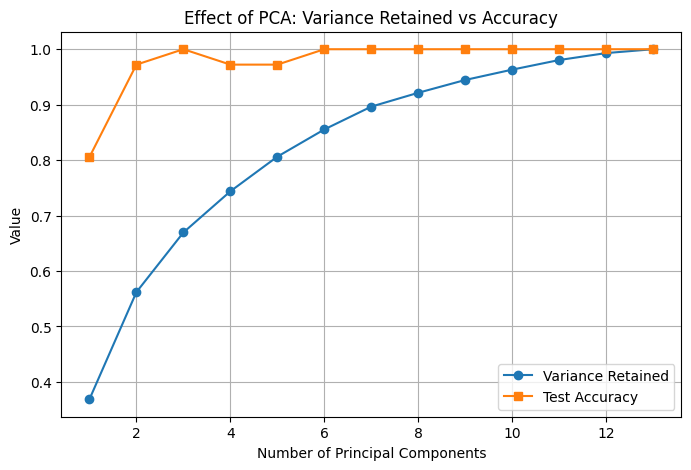

In [9]:
import matplotlib.pyplot as plt

ks = [r[0] for r in results]
var_retained = [r[1] for r in results]
accs = [r[2] for r in results]

plt.figure(figsize=(8,5))
plt.plot(ks, var_retained, marker='o', label='Variance Retained')
plt.plot(ks, accs, marker='s', label='Test Accuracy')
plt.xlabel('Number of Principal Components')
plt.ylabel('Value')
plt.title('Effect of PCA: Variance Retained vs Accuracy')
plt.legend()
plt.grid(True)
plt.show()